In [1]:
import numpy as np
from brian2 import *
from sklearn.datasets import fetch_openml
from network_garg import *
from utils import *
from tqdm.notebook import tqdm
import gc

prefs.codegen.target = 'cython'
# prefs.codegen.target = 'numpy'

In [2]:
mnist = fetch_openml('mnist_784', data_home='../mnist_data/', as_frame=False, parser='liac-arff')

X = mnist.data
y = mnist.target
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(60000, 784), y=(60000,)
Test shapes: X=(10000, 784), y=(10000,)


In [3]:
net, inp_group, spike_monitor = build_network_train()

In [4]:
# num_training_images = 100

# for i in tqdm(range(num_training_images)):
#     image = X[i]
#     pixel_values = np.clip(image / 255.0, 0.0, 1.0)
#     inp_group.I = pixel_values * volt
#     net.run(time_per_img)
#     inp_group.I = 0 * volt
#     net.run(50 * ms)

# print("Training complete. Total spikes in excitatory layer:", spike_monitor.num_spikes)

In [5]:
num_examples = 1000
batch_size = 100
num_batches = num_examples // batch_size

time_per_block = 50 * ms
blocks_per_image = 7  # 350ms presentation
blocks_per_rest = 3   # 150ms rest
total_blocks = blocks_per_image + blocks_per_rest  # 10 blocks (500ms) total
batch_duration = batch_size * total_blocks * time_per_block

In [6]:
for batch_idx in range(num_batches):
    print(f"\n--- Batch {batch_idx + 1} / {num_batches} ---")

    batch_start_time = batch_idx * batch_duration
    
    # Slice the dataset for this specific batch
    start_img = batch_idx * batch_size
    end_img = start_img + batch_size
    X_batch = X_train[start_img : end_img]
    
    # Prepare the array for this batch
    rates_array = np.zeros((batch_size * total_blocks, n_input), dtype=np.float32)

    print("Preparing batch data...")
    for idx in tqdm(range(batch_size)):
        img_rates = X_batch[idx] / 255.0 
        start_idx_arr = idx * total_blocks
        rates_array[start_idx_arr : start_idx_arr + blocks_per_image, :] = img_rates
        
    # Overwrite
    pixel_input = TimedArray(rates_array, dt=time_per_block) 
    t_offset = batch_start_time
    
    net.run(batch_duration, namespace=globals(), report='text', report_period=120*second)
    
    # Cleanup to save RAM
    del rates_array
    gc.collect()


--- Batch 1 / 10 ---
Preparing batch data...


  0%|          | 0/100 [00:00<?, ?it/s]

Starting simulation at t=0. s for a duration of 50. s
50. s (100%) simulated in 1m 20s

--- Batch 2 / 10 ---
Preparing batch data...


  0%|          | 0/100 [00:00<?, ?it/s]

Starting simulation at t=50. s for a duration of 50. s
50. s (100%) simulated in 1m 20s

--- Batch 3 / 10 ---
Preparing batch data...


...

Starting simulation at t=0.35 ks for a duration of 50. s
50. s (100%) simulated in 1m 17s

--- Batch 9 / 10 ---
Preparing batch data...


  0%|          | 0/100 [00:00<?, ?it/s]

Starting simulation at t=0.4 ks for a duration of 50. s
50. s (100%) simulated in 1m 17s

--- Batch 10 / 10 ---
Preparing batch data...


  0%|          | 0/100 [00:00<?, ?it/s]

Starting simulation at t=0.45 ks for a duration of 50. s
50. s (100%) simulated in 1m 17s


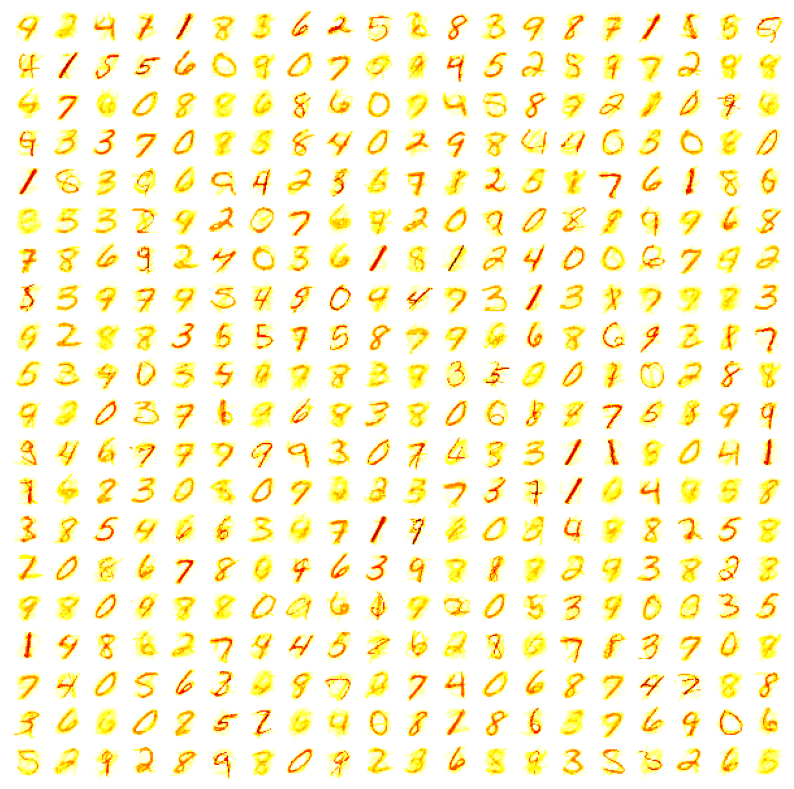

In [7]:
final_weights = get_2d_weights(net['s_inp_exc'], n_input, n_e)
plot_weights(final_weights, n_e)